# Decoded Plots

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

csv_path = Path("../../output/decoded.csv")
no_audio_compression = Path("../../output/encode_decode_no_wa.csv")

df_actual = pd.read_csv(csv_path)
df_best = pd.read_csv(no_audio_compression)

# Backward compatibility for cells that still reference `df`.
df = df_actual

In this set, `volume_noise` is fixed at `0.01`.
Each message is evaluated across combinations of `frequency` and `volume_gain_data`.
The plots below fix one message at a time to show how frequency and data volume affect error rate.
The test messages are the following:

In [58]:
messages = df_actual["message"].unique()
for message in messages:
    print(f"{repr(message)}")

'Hi!'
'Hello world, this is a 123456 message!'
'Special symbols: @#$%^&*+=_|~`<>/.,;:!?-()[]{}\\'
'Line breaks test:\nFirst line\nSecond line\nThird line\nTabs and spacing: col1\tcol2\tcol3'
'Long message: This is a significantly longer test payload intended to simulate realistic secret content with multiple sentence-like fragments, numbers like 2026, and enough characters to stress encoding/decoding across different audio samples.'


## Purpose of these plots
In this file we compare the results obtained through the WhatsApp compression (sending and audio, downloading it and decoding it) and the results obtained just with encoding and decoding. The pipeline is the same:
- data encoding
- adding white noise
- adding voice recordings

What differs is the WhatsApp compression. This work shows the degradation in the error rate when the compression takes place.

## Message-wise Frequency and Data Volume Plots

In [66]:
from pandas import DataFrame
import numpy as np
from matplotlib.axes import Axes
from typing import Optional


def format_float_label(value: float, decimals: int = 2) -> str:
    return f"{value:.{decimals}f}".rstrip("0").rstrip(".")


def shorten_message(text: object, max_len: int = 70) -> str:
    clean = " ".join(str(text).split())
    if len(clean) <= max_len:
        return clean
    return clean[: max_len - 3] + "..."


def format_frequency_label(value: object) -> str:
    numeric_f: Optional[float] = None
    if isinstance(value, (int, float, np.integer, np.floating)):
        numeric_f = float(value)
    elif isinstance(value, str):
        try:
            numeric_f = float(value)
        except ValueError:
            return value
    else:
        return str(value)

    if np.isclose(numeric_f, round(numeric_f)):
        return str(int(round(numeric_f)))
    return format_float_label(numeric_f, decimals=3)


def prepare_plot_df(df: DataFrame) -> DataFrame:
    plot_df = df.copy()

    if "status" in plot_df.columns:
        plot_df = plot_df[plot_df["status"].astype(str).str.lower() == "success"]

    for col in ["frequency", "volume_gain_data", "error_rate"]:
        plot_df[col] = pd.to_numeric(plot_df[col], errors="coerce")

    plot_df = plot_df.dropna(subset=["message", "frequency", "volume_gain_data", "error_rate"])
    plot_df["message_label"] = plot_df["message"].astype(str)
    return plot_df


def _build_message_list(df_a: DataFrame, df_b: DataFrame) -> list[str]:
    messages_a = prepare_plot_df(df_a)["message_label"].drop_duplicates().tolist()
    messages_b = prepare_plot_df(df_b)["message_label"].drop_duplicates().tolist()
    return list(dict.fromkeys(messages_a + messages_b))


def _build_heatmap_pivot(plot_df: DataFrame, message: str) -> Optional[DataFrame]:
    subset = plot_df[plot_df["message_label"] == message]
    if subset.empty:
        return None

    pivot = (
        subset.pivot_table(
            index="volume_gain_data",
            columns="frequency",
            values="error_rate",
            aggfunc="mean",
        )
        .sort_index()
        .sort_index(axis=1)
    )

    return None if pivot.empty else pivot


def _draw_heatmap_on_axis(ax: Axes, pivot: DataFrame, panel_title: str):
    image = ax.imshow(
        pivot.values,
        cmap="viridis",
        aspect="auto",
        origin="lower",
        vmin=0,
        vmax=1,
    )

    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([format_frequency_label(v) for v in pivot.columns], rotation=45, ha="right")
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([format_float_label(v, decimals=3) for v in pivot.index])

    ax.set_xlabel("Frequency")
    ax.set_ylabel("Volume Gain Data")
    ax.set_title(panel_title)
    return image


def plot_error_rate_heatmaps_by_message_comparison(
    df_a: DataFrame,
    df_b: DataFrame,
    label_a: str = "WhatsApp compression",
    label_b: str = "Best case",
) -> None:
    plot_a = prepare_plot_df(df_a)
    plot_b = prepare_plot_df(df_b)
    messages = _build_message_list(df_a, df_b)

    for message in messages:
        pivot_a = _build_heatmap_pivot(plot_a, message)
        pivot_b = _build_heatmap_pivot(plot_b, message)

        if pivot_a is None and pivot_b is None:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(19, 5), sharey=True)
        image = None

        if pivot_a is None:
            axes[0].text(0.5, 0.5, "No data", ha="center", va="center")
            axes[0].set_title(label_a)
            axes[0].set_axis_off()
        else:
            image = _draw_heatmap_on_axis(axes[0], pivot_a, label_a)

        if pivot_b is None:
            axes[1].text(0.5, 0.5, "No data", ha="center", va="center")
            axes[1].set_title(label_b)
            axes[1].set_axis_off()
        else:
            image = _draw_heatmap_on_axis(axes[1], pivot_b, label_b)

        fig.suptitle(f"Error Rate Heatmap | Message: {shorten_message(message)}", y=0.98)
        if image is not None:
            fig.subplots_adjust(right=0.88, top=0.84, wspace=0.18)
            color_bar = fig.colorbar(
                image,
                ax=axes.ravel().tolist(),
                fraction=0.035,
                pad=0.03,
            )
            color_bar.set_label("Error Rate")
        else:
            fig.subplots_adjust(top=0.84, wspace=0.18)

        plt.show()


def _plot_error_rate_lines_on_axis(ax: Axes, subset: DataFrame, panel_title: str) -> None:
    if subset.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(panel_title)
        ax.set_axis_off()
        return

    for frequency, grouped in subset.groupby("frequency"):
        grouped = grouped.sort_values("volume_gain_data")
        ax.plot(
            grouped["volume_gain_data"],
            grouped["error_rate"],
            marker="o",
            linewidth=2,
            markersize=5,
            label=f"Freq: {format_frequency_label(frequency)}",
        )

    ax.set_xlabel("Volume Gain Data")
    ax.set_ylabel("Error Rate")
    ax.set_ylim(0, 1)
    ax.set_title(panel_title)
    ax.legend(
        title="Frequency",
        loc="upper center",
        bbox_to_anchor=(0.5, -0.2),
        ncol=3,
        frameon=False,
    )
    ax.grid(True, alpha=0.3)


def plot_error_rate_vs_frequency_by_message_comparison(
    df_a: DataFrame,
    df_b: DataFrame,
    label_a: str = "WhatsApp compression",
    label_b: str = "Best case",
) -> None:
    plot_a = prepare_plot_df(df_a)
    plot_b = prepare_plot_df(df_b)
    messages = _build_message_list(df_a, df_b)

    for message in messages:
        subset_a = plot_a[plot_a["message_label"] == message]
        subset_b = plot_b[plot_b["message_label"] == message]

        if subset_a.empty and subset_b.empty:
            continue

        fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True)
        _plot_error_rate_lines_on_axis(axes[0], subset_a, label_a)
        _plot_error_rate_lines_on_axis(axes[1], subset_b, label_b)
        fig.suptitle(
            f"Error Rate vs Volume Gain Data | Message: {shorten_message(message)}",
            y=1.03,
        )
        plt.tight_layout()
        plt.show()


def _select_volume_subset(plot_df: DataFrame, fixed_volume_gain_data: float, atol: float = 1e-9):
    available_values = np.sort(plot_df["volume_gain_data"].dropna().astype(float).unique())
    if available_values.size == 0:
        return plot_df.iloc[0:0], fixed_volume_gain_data, False

    subset = plot_df[np.isclose(plot_df["volume_gain_data"], fixed_volume_gain_data, atol=atol)]
    used_volume = fixed_volume_gain_data

    if subset.empty:
        nearest = float(available_values[np.argmin(np.abs(available_values - fixed_volume_gain_data))])
        subset = plot_df[np.isclose(plot_df["volume_gain_data"], nearest, atol=atol)]
        used_volume = nearest

    fallback = not np.isclose(used_volume, fixed_volume_gain_data, atol=atol)
    return subset, used_volume, fallback


def _draw_variance_distribution_on_axis(
    ax: Axes,
    subset: DataFrame,
    panel_title: str,
    prefer_box_if_sparse: bool,
    min_points_per_group: int,
) -> None:
    if subset.empty:
        ax.text(0.5, 0.5, "No data", ha="center", va="center")
        ax.set_title(panel_title)
        ax.set_axis_off()
        return

    frequencies = sorted(subset["frequency"].dropna().astype(float).unique().tolist())
    data = [np.asarray(subset.loc[subset["frequency"] == freq, "error_rate"], dtype=float) for freq in frequencies]
    counts = np.array([len(values) for values in data])
    use_box_plot = prefer_box_if_sparse and (counts < min_points_per_group).any()

    x_positions = np.arange(1, len(frequencies) + 1)

    if use_box_plot:
        ax.boxplot(
            data,
            positions=x_positions,
            patch_artist=True,
            boxprops={"facecolor": "#8ecae6", "alpha": 0.65},
            medianprops={"color": "#023047", "linewidth": 2},
        )
        chart_type = "Box"
    else:
        parts = ax.violinplot(
            data,
            positions=x_positions,
            widths=0.85,
            showmeans=False,
            showmedians=True,
            showextrema=True,
        )
        bodies = parts.get("bodies", [])
        if isinstance(bodies, list):
            for body in bodies:
                body.set_facecolor("#ffb703")
                body.set_edgecolor("#023047")
                body.set_alpha(0.7)
        chart_type = "Violin"

    rng = np.random.default_rng(seed=7)
    for idx, values in enumerate(data, start=1):
        values_arr = np.asarray(values, dtype=float)
        jitter = rng.uniform(-0.07, 0.07, size=len(values_arr))
        ax.scatter(
            np.full(len(values_arr), idx) + jitter,
            values_arr,
            s=16,
            alpha=0.55,
            color="#1d3557",
            linewidths=0,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels([format_frequency_label(freq) for freq in frequencies])
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Error Rate")
    ax.set_ylim(0, 1)
    ax.grid(axis="y", alpha=0.25)
    ax.set_title(f"{panel_title} | {chart_type}")


def plot_error_rate_variance_by_frequency_comparison(
    df_a: DataFrame,
    df_b: DataFrame,
    fixed_volume_gain_data: float,
    label_a: str = "WhatsApp compression",
    label_b: str = "Best case",
    prefer_box_if_sparse: bool = True,
    min_points_per_group: int = 3,
    atol: float = 1e-9,
) -> None:
    plot_a = prepare_plot_df(df_a)
    plot_b = prepare_plot_df(df_b)

    subset_a, used_a, fallback_a = _select_volume_subset(plot_a, fixed_volume_gain_data, atol=atol)
    subset_b, used_b, fallback_b = _select_volume_subset(plot_b, fixed_volume_gain_data, atol=atol)

    if subset_a.empty and subset_b.empty:
        raise ValueError("No rows available for the selected 'volume_gain_data' in either dataset.")

    fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)
    _draw_variance_distribution_on_axis(
        axes[0],
        subset_a,
        f"{label_a} | volume_gain_data={format_float_label(used_a, 6)}",
        prefer_box_if_sparse,
        min_points_per_group,
    )
    _draw_variance_distribution_on_axis(
        axes[1],
        subset_b,
        f"{label_b} | volume_gain_data={format_float_label(used_b, 6)}",
        prefer_box_if_sparse,
        min_points_per_group,
    )

    fig.suptitle(
        "Error Rate Variance by Frequency (Comparison)",
        y=1.02,
    )
    plt.tight_layout()
    plt.show()

    if fallback_a:
        print(
            "WhatsApp compression requested volume_gain_data not found exactly; "
            f"using nearest value {used_a:.6f}."
        )
    if fallback_b:
        print(
            "Best case requested volume_gain_data not found exactly; "
            f"using nearest value {used_b:.6f}."
        )


def plot_error_rate_variance_for_all_volume_gains_comparison(
    df_a: DataFrame,
    df_b: DataFrame,
    prefer_box_if_sparse: bool = True,
    min_points_per_group: int = 3,
) -> None:
    plot_a = prepare_plot_df(df_a)
    plot_b = prepare_plot_df(df_b)

    volume_values_a = set(plot_a["volume_gain_data"].dropna().astype(float).unique().tolist())
    volume_values_b = set(plot_b["volume_gain_data"].dropna().astype(float).unique().tolist())
    volume_values = sorted(volume_values_a.union(volume_values_b))

    if not volume_values:
        raise ValueError("No valid 'volume_gain_data' values found after preprocessing.")

    print(f"Generating {len(volume_values)} comparison plots (one per volume_gain_data).")
    for volume_value in volume_values:
        plot_error_rate_variance_by_frequency_comparison(
            df_a,
            df_b,
            fixed_volume_gain_data=float(volume_value),
            prefer_box_if_sparse=prefer_box_if_sparse,
            min_points_per_group=min_points_per_group,
        )

## Error Rate Heatmaps by Message (Comparison)
Each figure is split into two columns:
- Column A: `csv_path` (actual pipeline result)
- Column B: `no_audio_compression` (best-case reference)

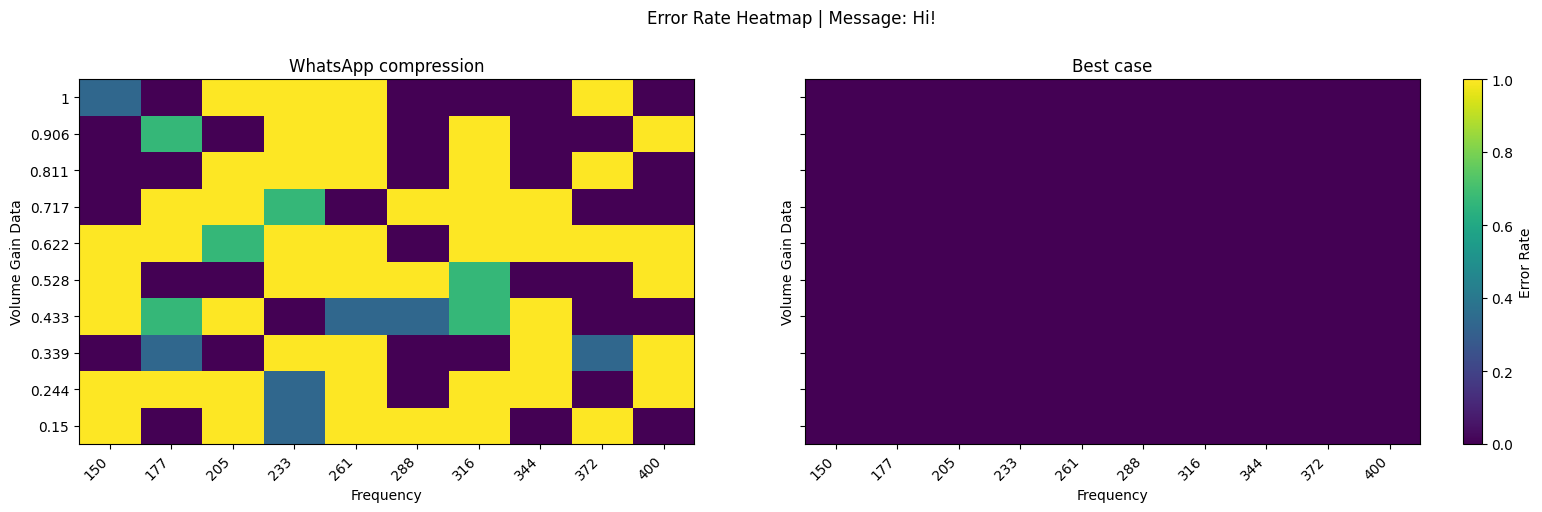

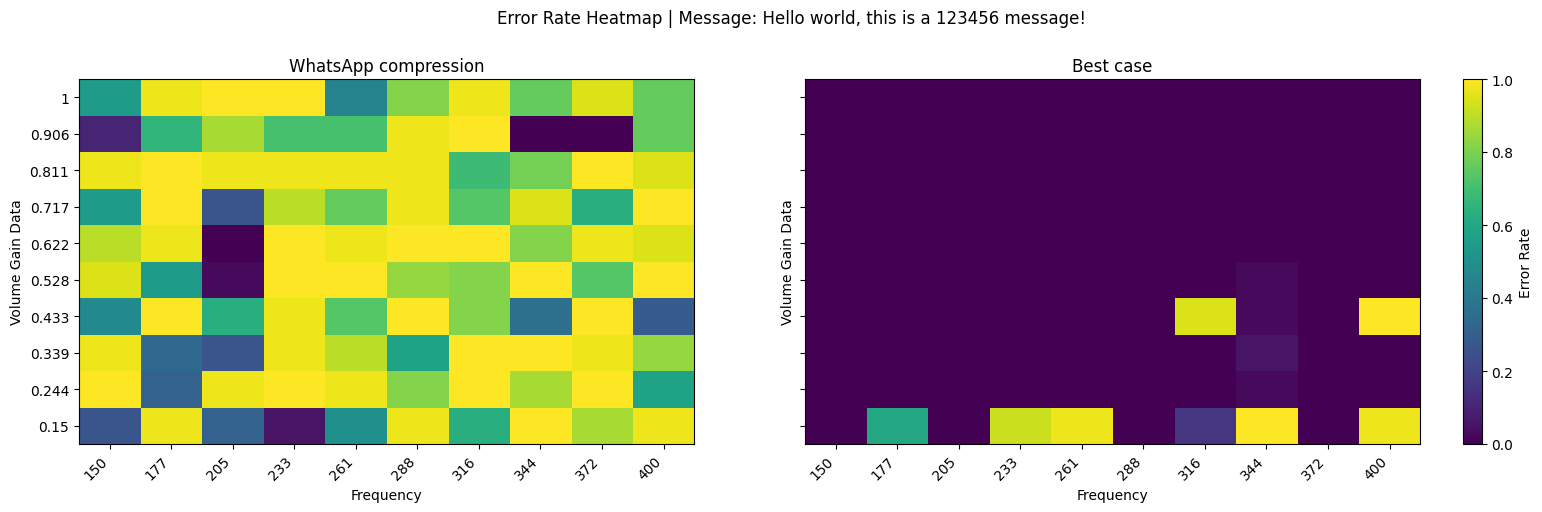

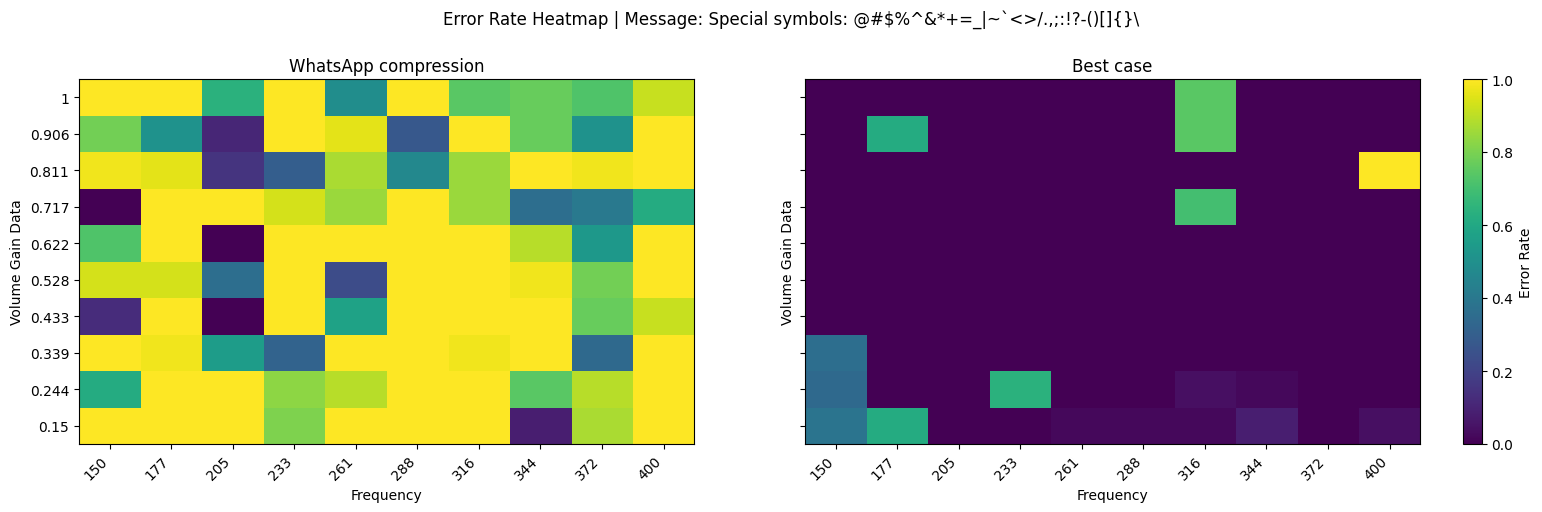

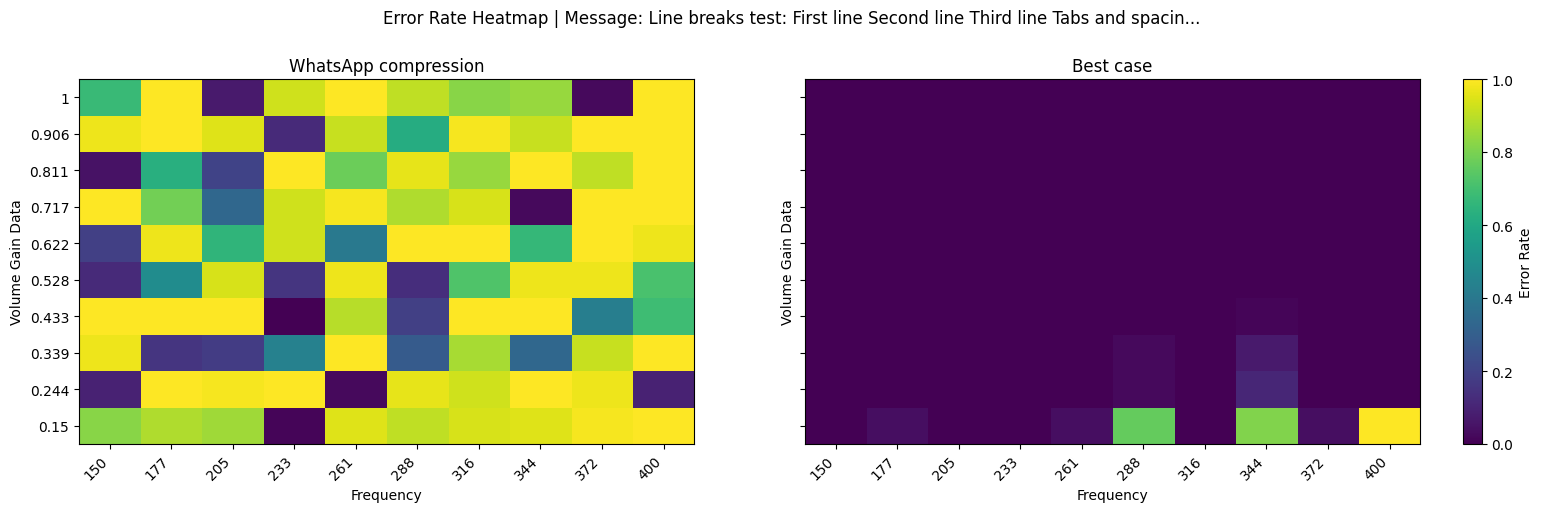

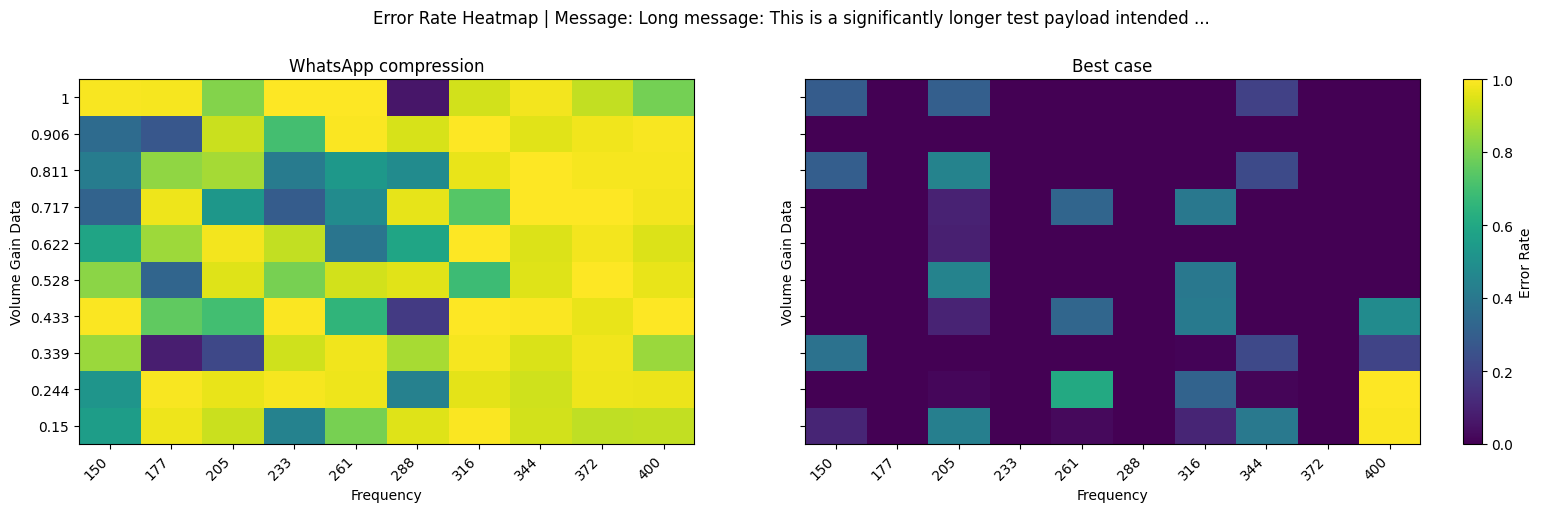

In [60]:
plot_error_rate_heatmaps_by_message_comparison(
    df_actual,
    df_best,
    label_a="WhatsApp compression",
    label_b="Best case",
)

## Error Rate vs Frequency (Comparison per Message)
Each figure is split into two columns for direct comparison between actual and best-case runs.

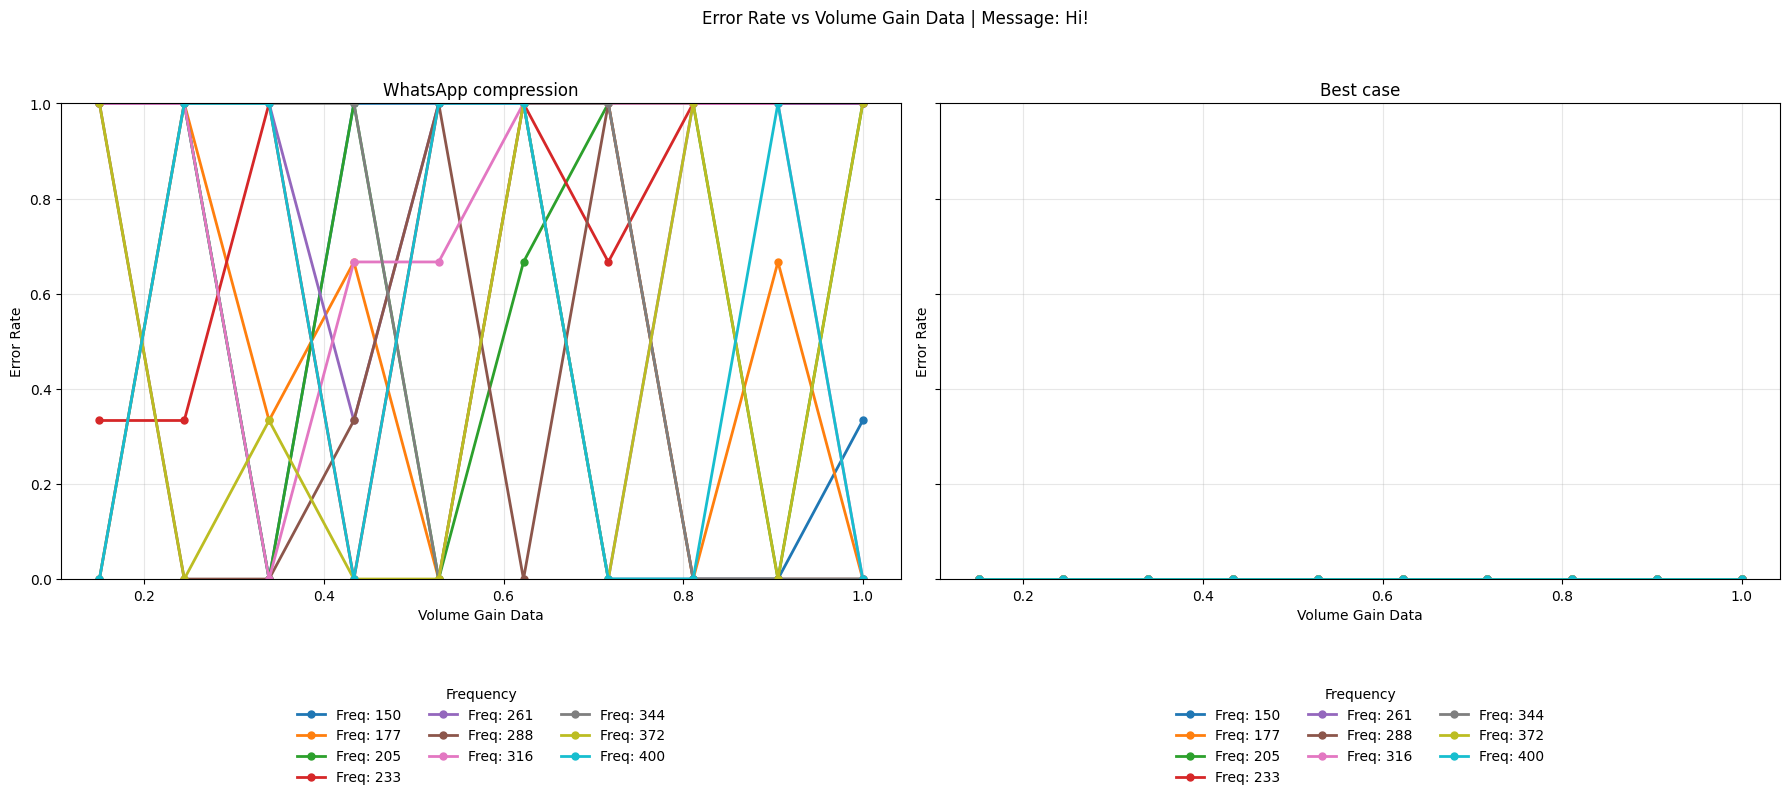

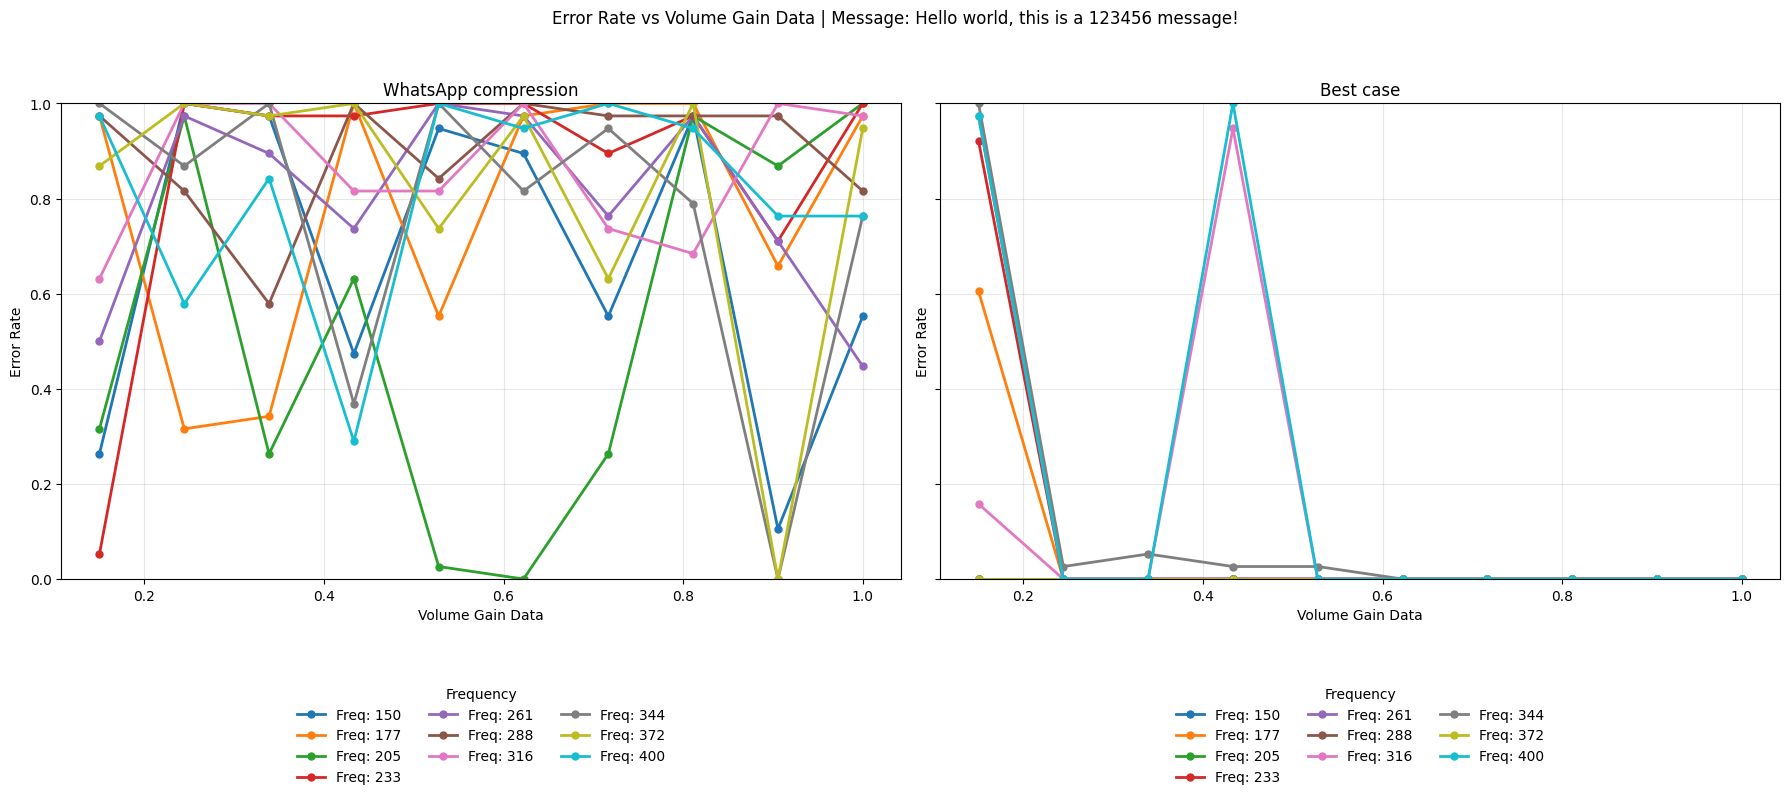

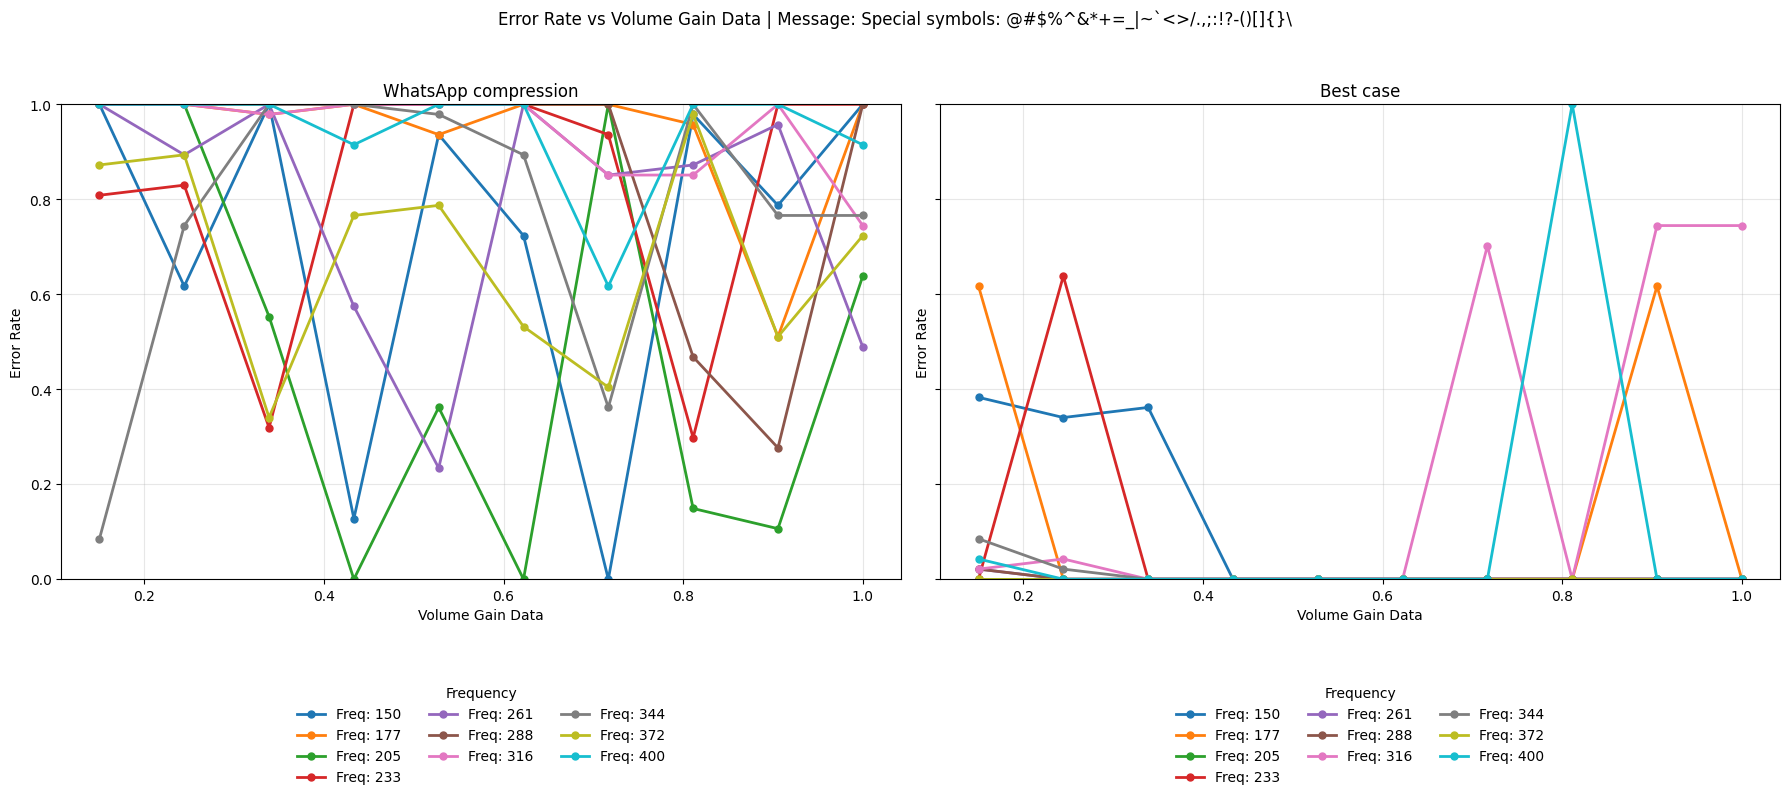

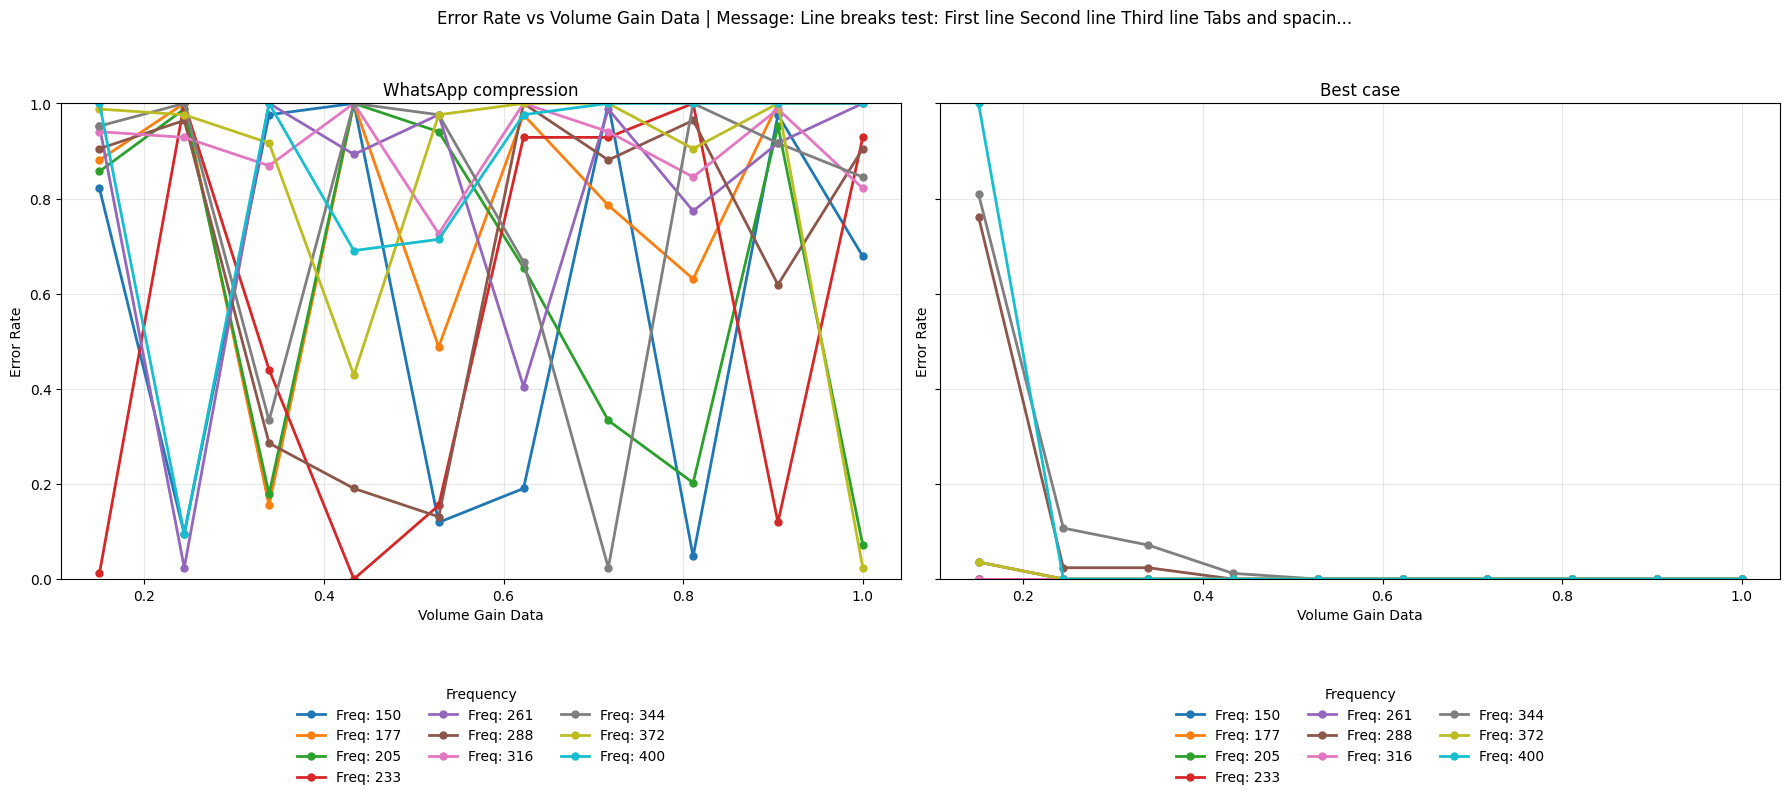

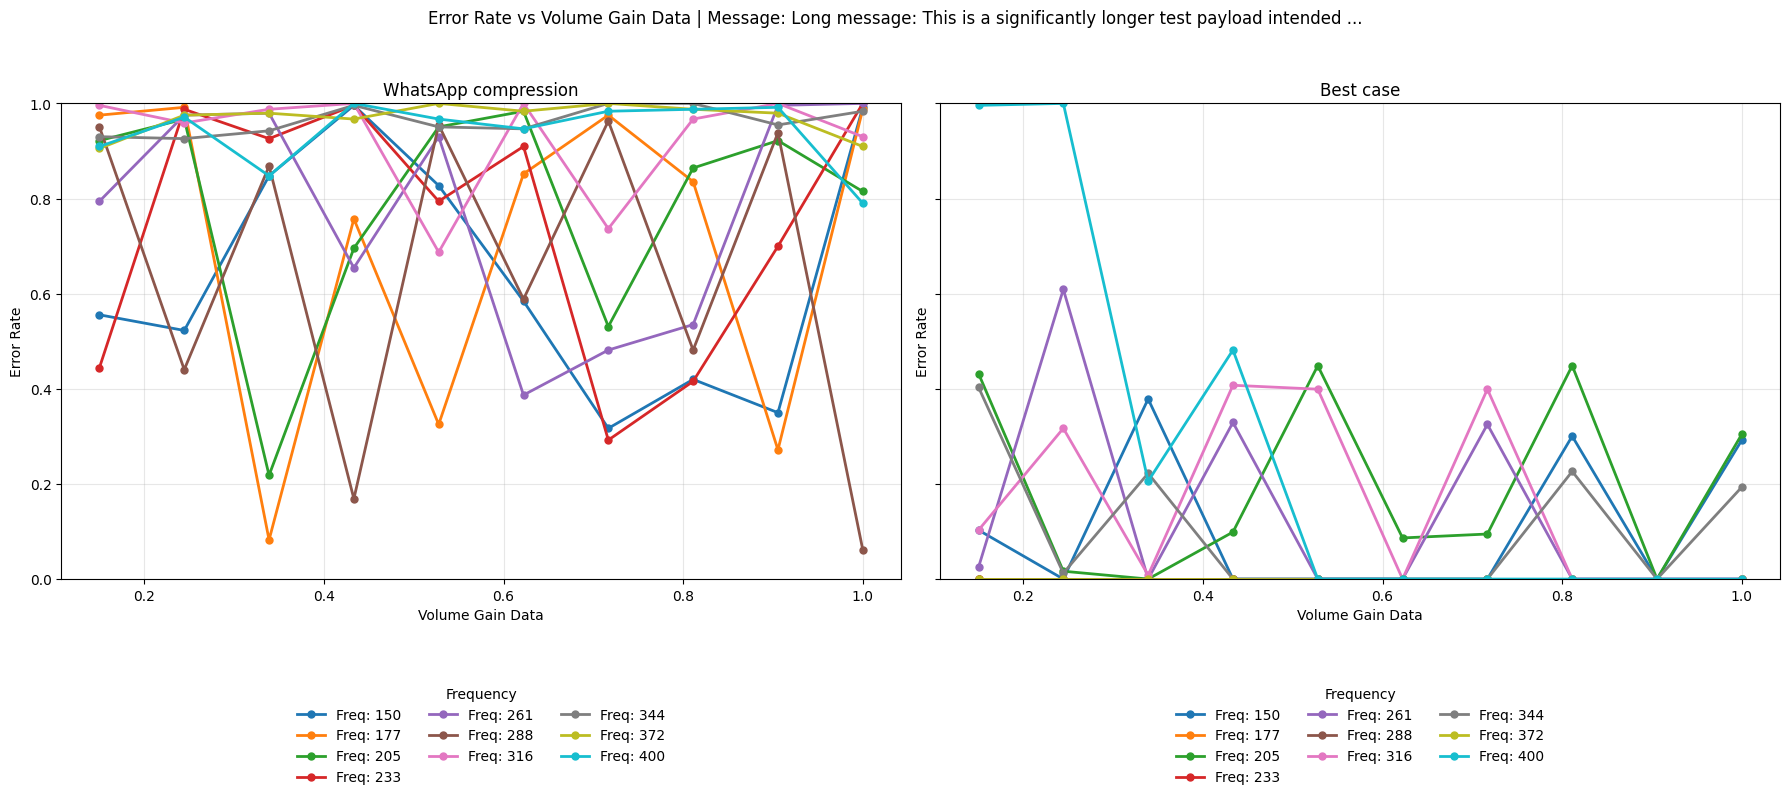

In [67]:
plot_error_rate_vs_frequency_by_message_comparison(
    df_actual,
    df_best,
    label_a="WhatsApp compression",
    label_b="Best case",
)

## Error Rate Variance by Frequency (All Volume Gain Data Values, Comparison)
This section generates one comparison figure per available `volume_gain_data` value.
Each figure has:
- Column A: `csv_path`
- Column B: `no_audio_compression`
Violin plots are used by default and automatically fall back to box plots when groups are sparse.

Generating 10 comparison plots (one per volume_gain_data).


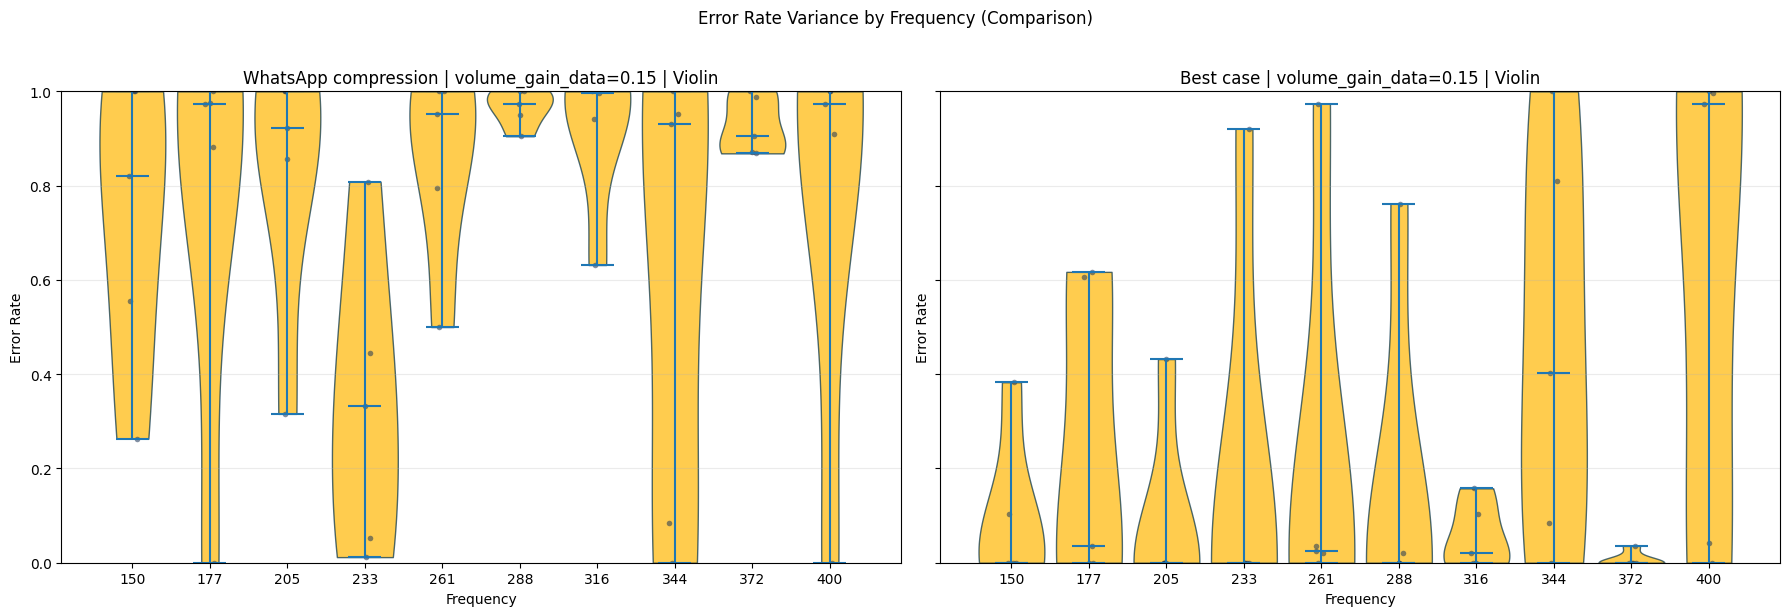

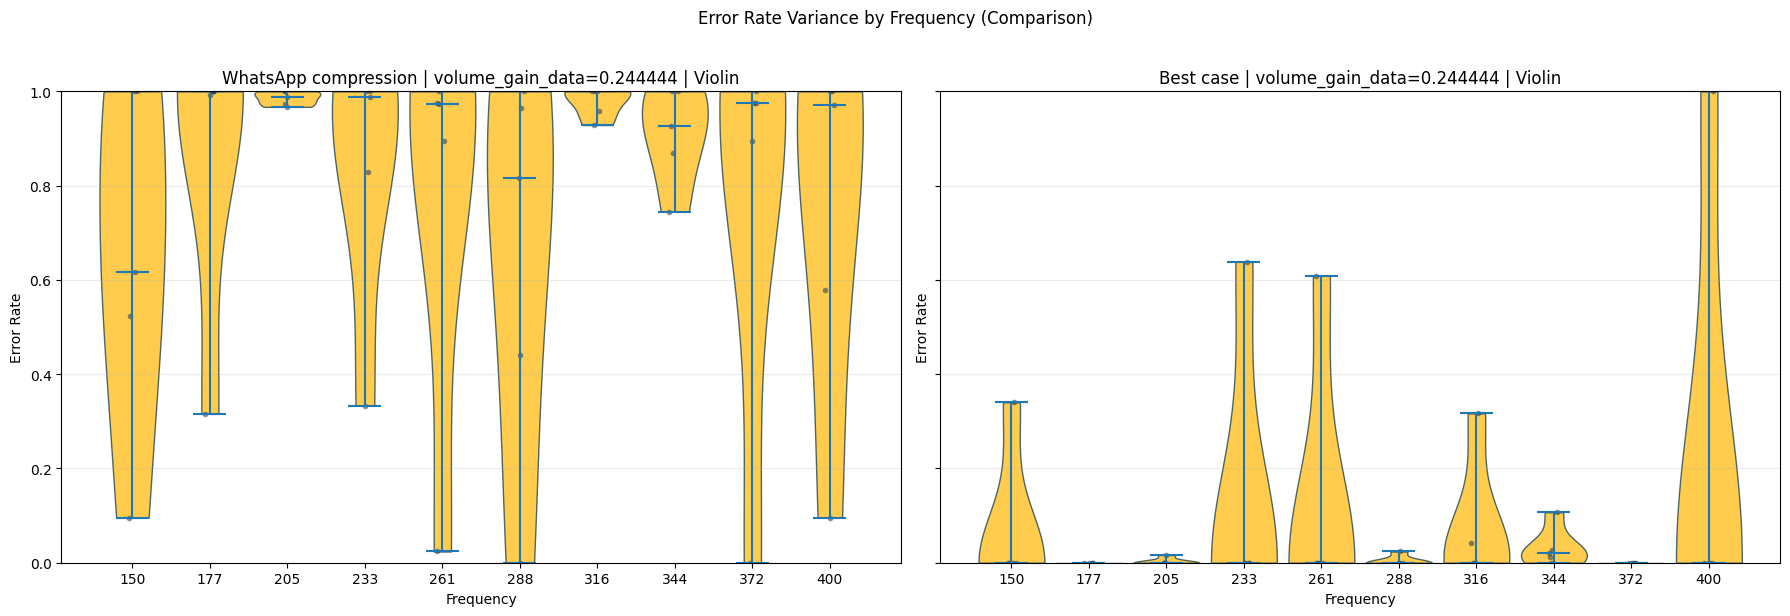

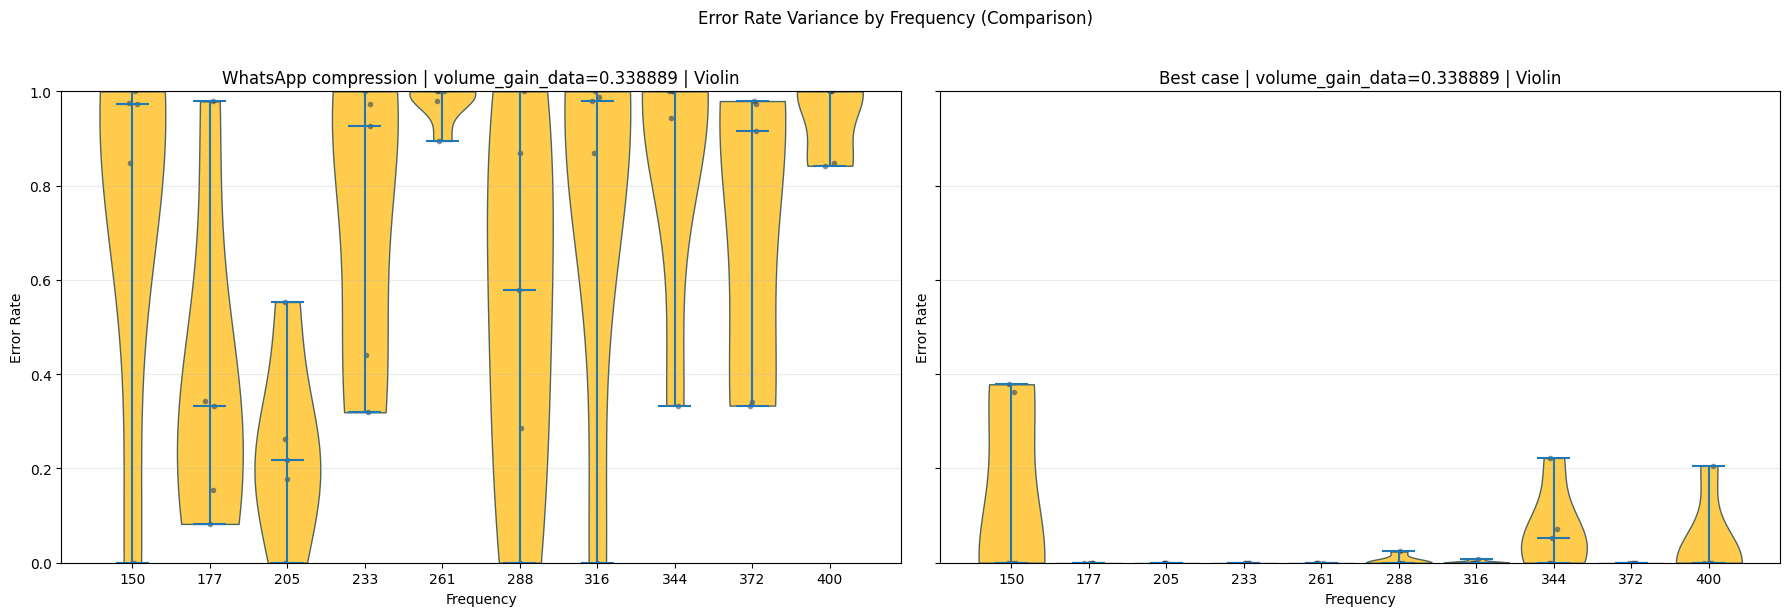

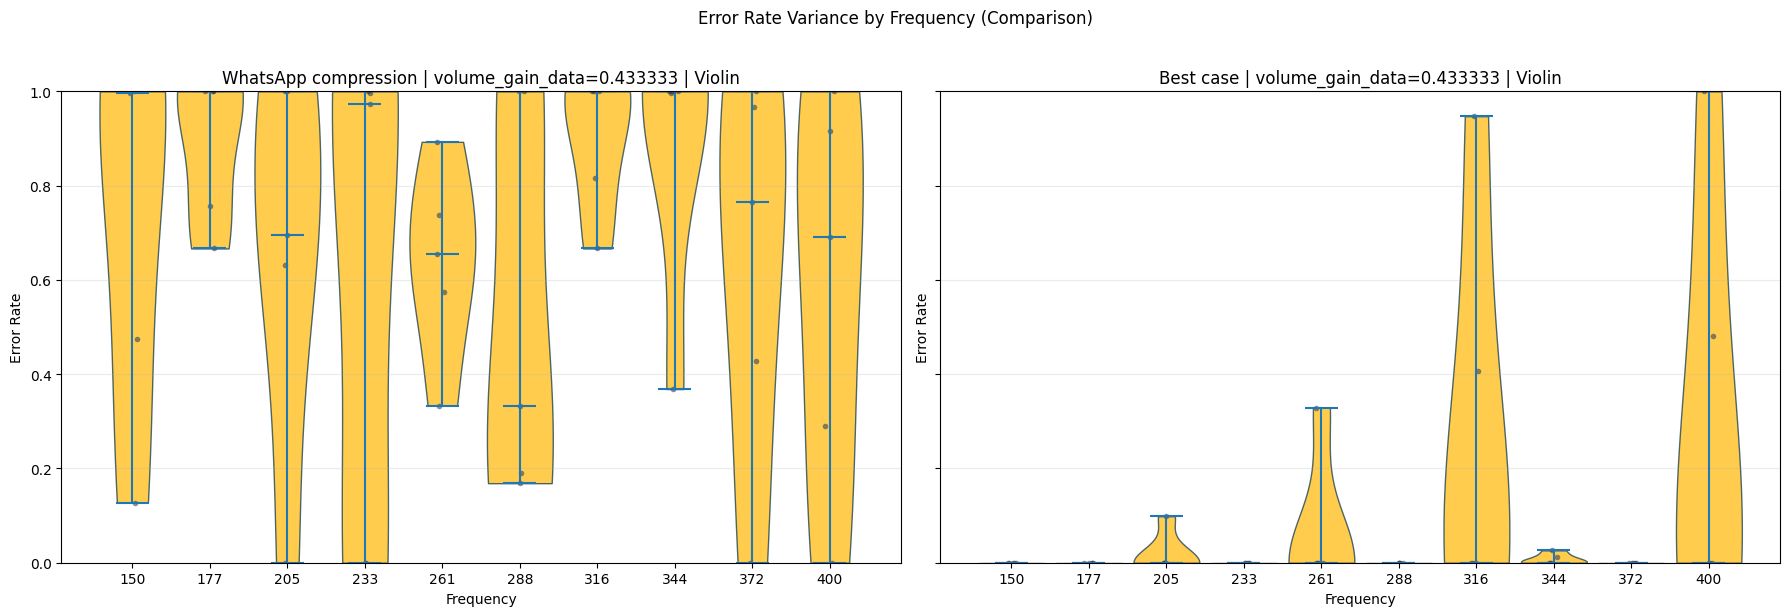

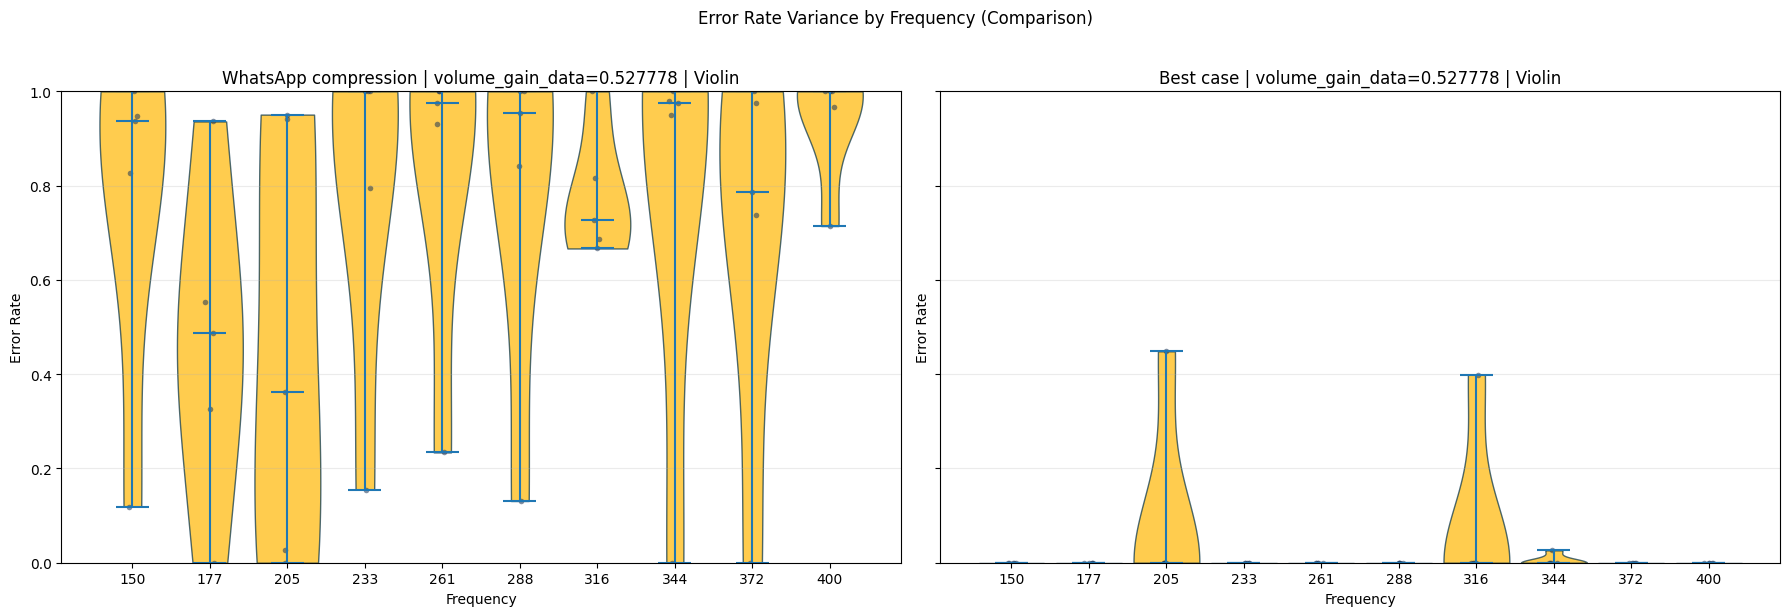

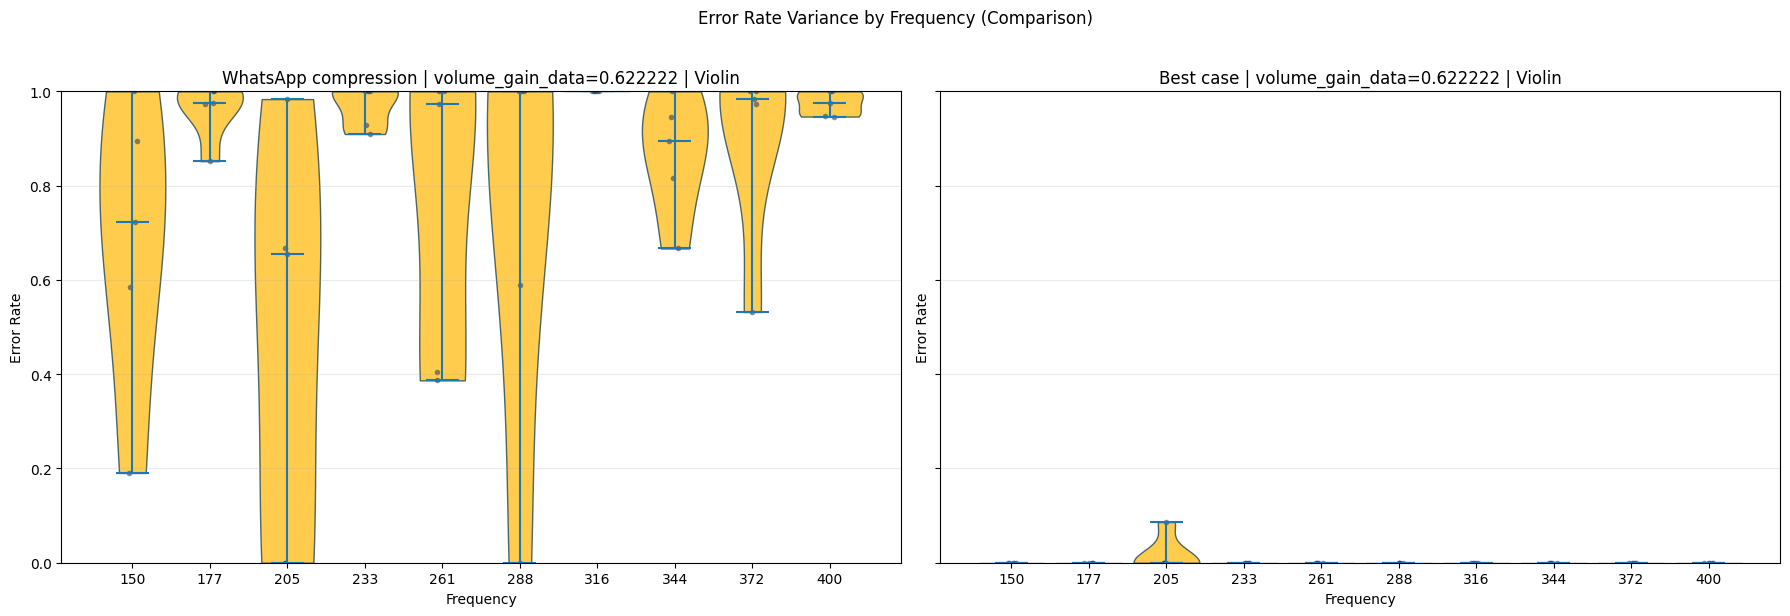

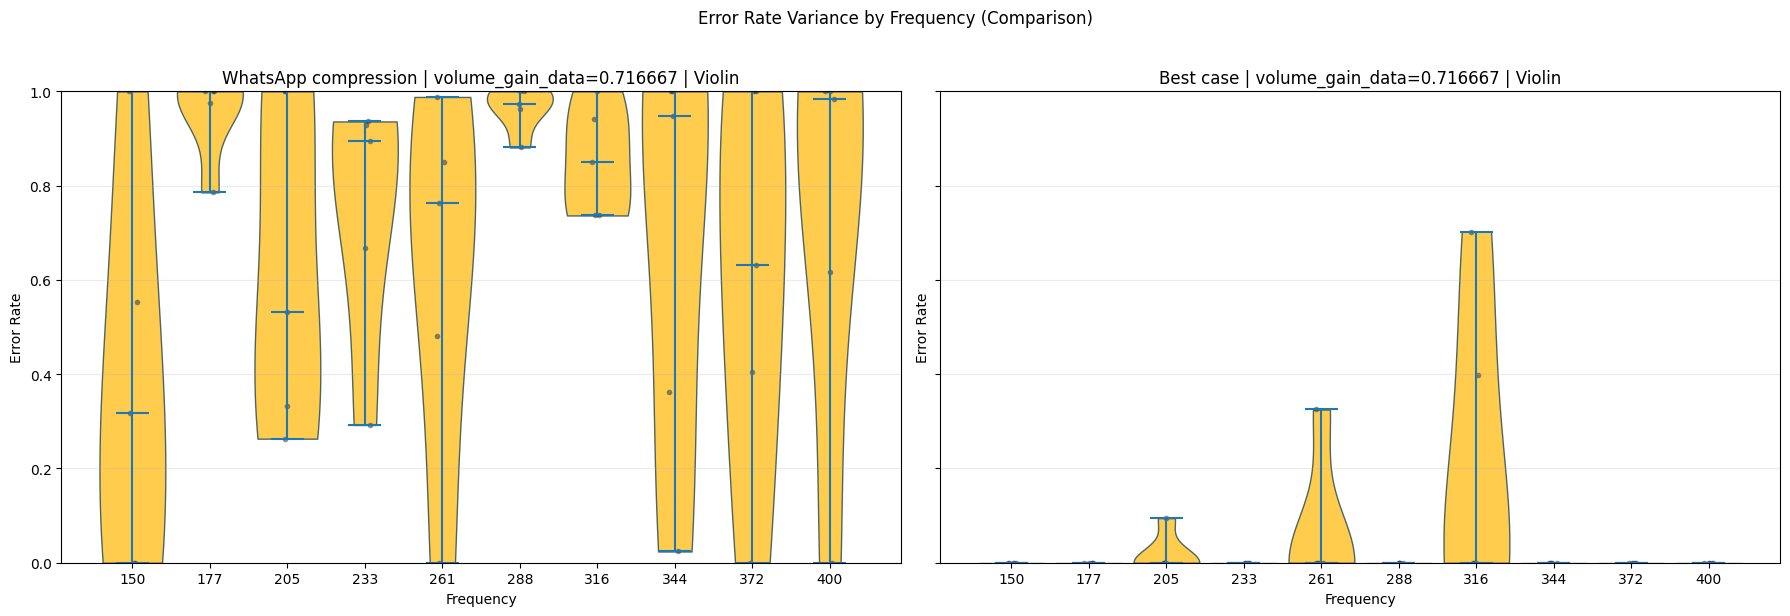

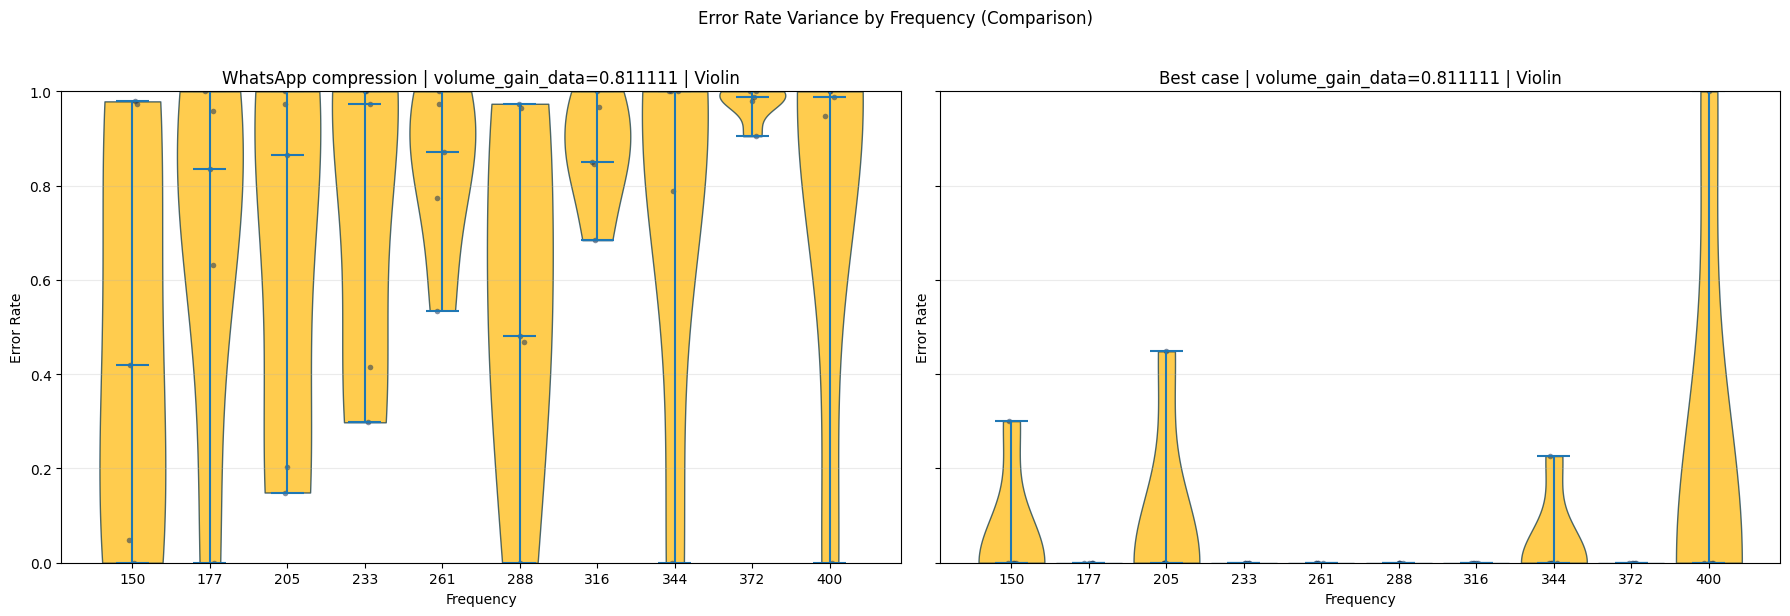

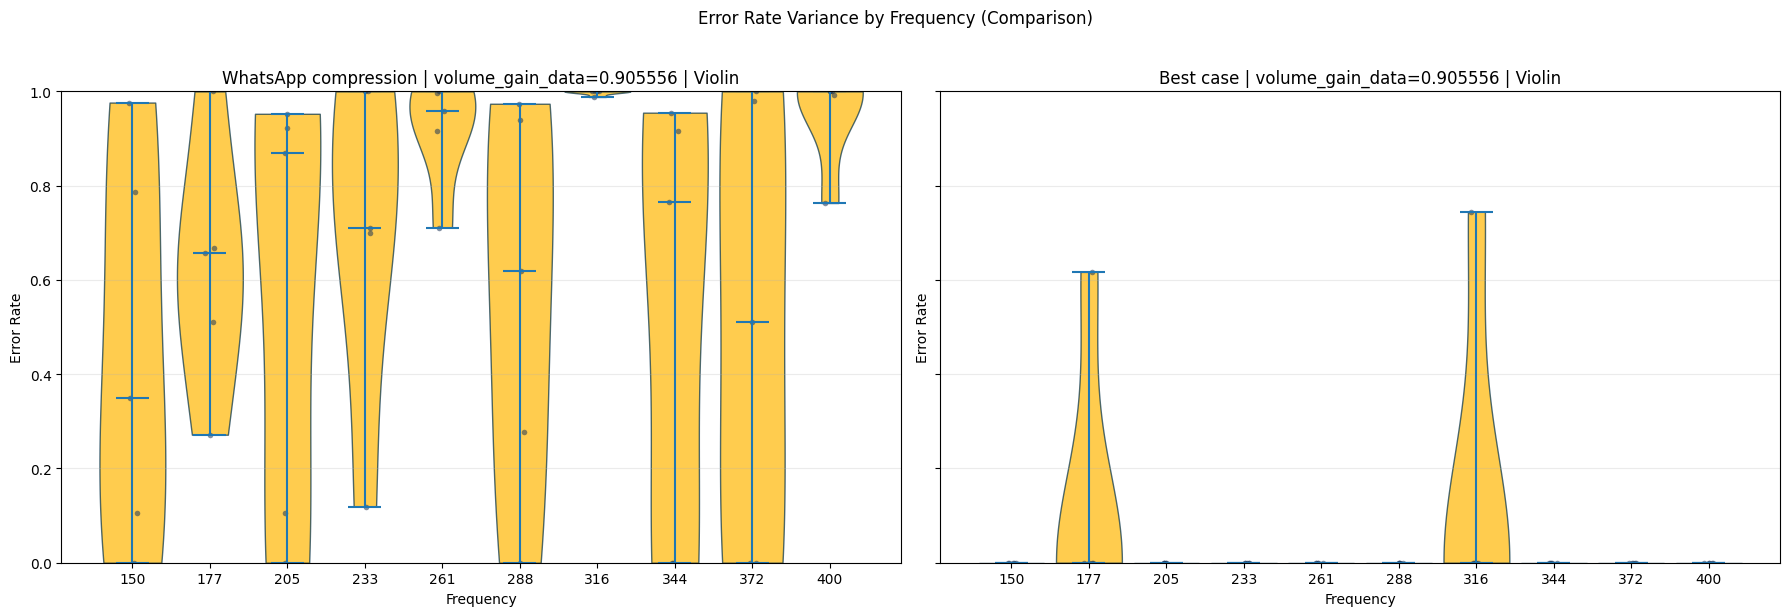

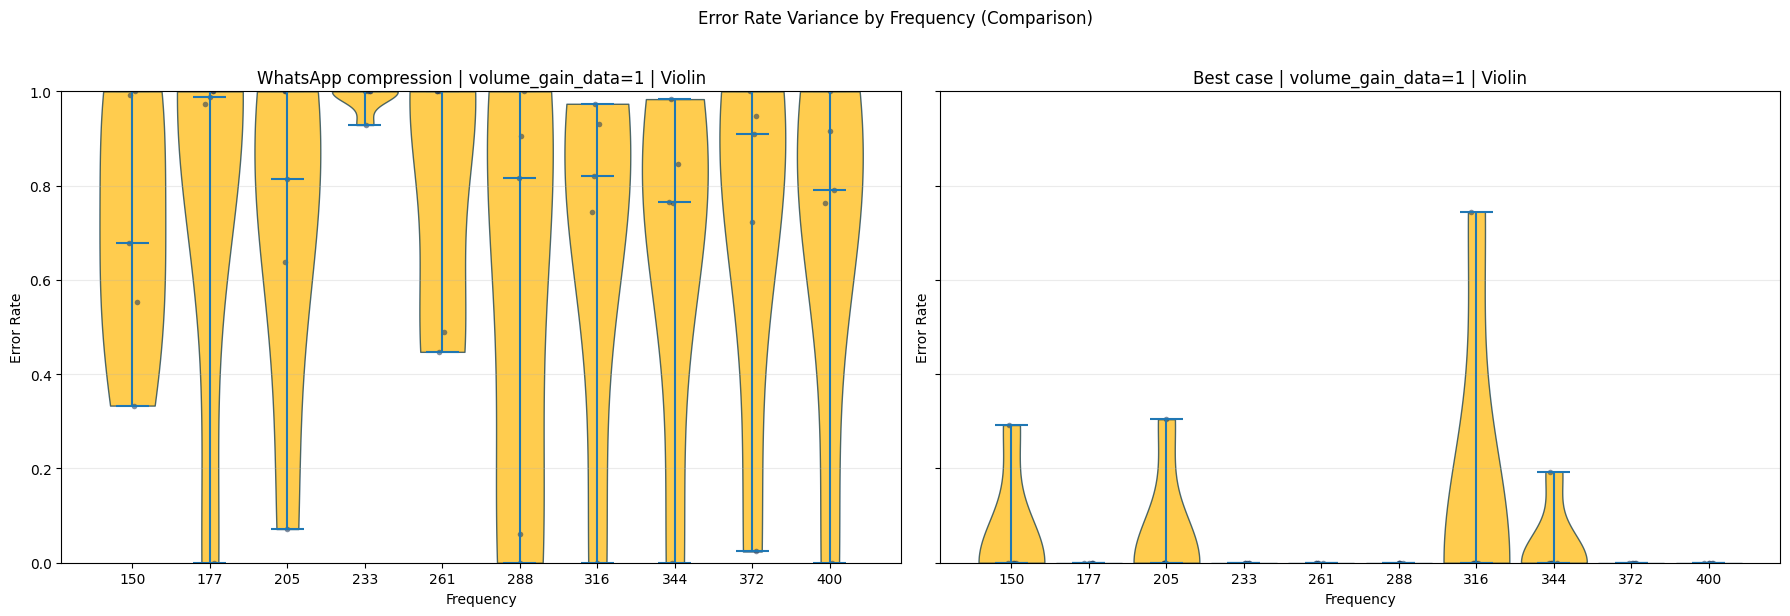

In [62]:
plot_error_rate_variance_for_all_volume_gains_comparison(
    df_actual,
    df_best,
    prefer_box_if_sparse=True,
    min_points_per_group=5,
)

## 3D Interaction: Frequency, Data Volume, and Message (Comparison)
This figure is split into two 3D panels:
- Column A: `csv_path` (actual pipeline output)
- Column B: `no_audio_compression` (best-case reference)
Color and marker size encode `error_rate` (lower is better).

In [63]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots


def _prepare_3d_plot_df(df: DataFrame) -> tuple[DataFrame, list[str]]:
    plot_df = prepare_plot_df(df).copy()
    plot_df["error_rate_clipped"] = plot_df["error_rate"].clip(0, 1)
    plot_df["marker_size"] = 6 + plot_df["error_rate_clipped"] * 18

    message_order = plot_df["message_label"].drop_duplicates().tolist()
    message_to_idx = {message: idx for idx, message in enumerate(message_order)}
    plot_df["message_idx"] = plot_df["message_label"].map(message_to_idx)
    plot_df["message_short"] = plot_df["message_label"].map(lambda m: shorten_message(m, 40))
    return plot_df, message_order


def _add_3d_trace(fig, plot_df: DataFrame, row: int, col: int, trace_name: str) -> None:
    fig.add_trace(
        go.Scatter3d(
            x=plot_df["frequency"],
            y=plot_df["volume_gain_data"],
            z=plot_df["message_idx"],
            mode="markers",
            name=trace_name,
            showlegend=False,
            marker={
                "size": plot_df["marker_size"],
                "color": plot_df["error_rate_clipped"],
                "coloraxis": "coloraxis",
                "opacity": 0.85,
                "line": {"width": 0.5, "color": "black"},
            },
            customdata=np.stack(
                [plot_df["message_short"], plot_df["error_rate"], plot_df["volume_gain_data"]],
                axis=-1,
            ),
            hovertemplate=(
                "Frequency=%{x}<br>"
                "Volume Gain Data=%{y:.6f}<br>"
                "Message=%{customdata[0]}<br>"
                "Error Rate=%{customdata[1]:.4f}<extra></extra>"
            ),
        ),
        row=row,
        col=col,
    )


def _scene_layout(message_order: list[str]) -> dict:
    return {
        "xaxis": {"title": "Frequency"},
        "yaxis": {"title": "Volume Gain Data"},
        "zaxis": {
            "title": "Message",
            "tickvals": list(range(len(message_order))),
            "ticktext": [shorten_message(message, 30) for message in message_order],
        },
        "camera": {"eye": {"x": 1.5, "y": 1.5, "z": 0.9}},
    }


plot_df_a, message_order_a = _prepare_3d_plot_df(df_actual)
plot_df_b, message_order_b = _prepare_3d_plot_df(df_best)

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{"type": "scene"}, {"type": "scene"}]],
    subplot_titles=(
        "Column A: WhatsApp compression",
        "Column B: Best case",
    ),
    horizontal_spacing=0.03,
)

if not plot_df_a.empty:
    _add_3d_trace(fig, plot_df_a, row=1, col=1, trace_name="A")
if not plot_df_b.empty:
    _add_3d_trace(fig, plot_df_b, row=1, col=2, trace_name="B")

fig.update_layout(
    scene=_scene_layout(message_order_a),
    scene2=_scene_layout(message_order_b),
    coloraxis={
        "colorscale": "Viridis",
        "cmin": 0,
        "cmax": 1,
        "colorbar": {"title": "Error Rate"},
    },
    title="3D Interaction Comparison: Frequency vs Data Volume vs Message",
    margin={"l": 0, "r": 0, "t": 60, "b": 0},
    height=850,
)

fig.show()